In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('application_record.csv')

In [4]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [6]:
employed = df[df['DAYS_EMPLOYED']< 0] 

In [7]:
employed

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438547,6839917,F,N,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-10966,-2704,1,0,0,0,NaN,2.0
438548,6839936,M,Y,Y,1,135000.0,Working,Secondary / secondary special,Married,House / apartment,-12569,-2095,1,0,0,0,Laborers,3.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0


In [9]:
employed[['DAYS_BIRTH', 'DAYS_EMPLOYED']]

,DAYS_BIRTH,DAYS_EMPLOYED
0,-12005,-4542
1,-12005,-4542
2,-21474,-1134
3,-19110,-3051
4,-19110,-3051
...,...,...
438547,-10966,-2704
438548,-12569,-2095
438553,-15939,-3007
438554,-8169,-372


<Axes: xlabel='DAYS_BIRTH', ylabel='DAYS_EMPLOYED'>

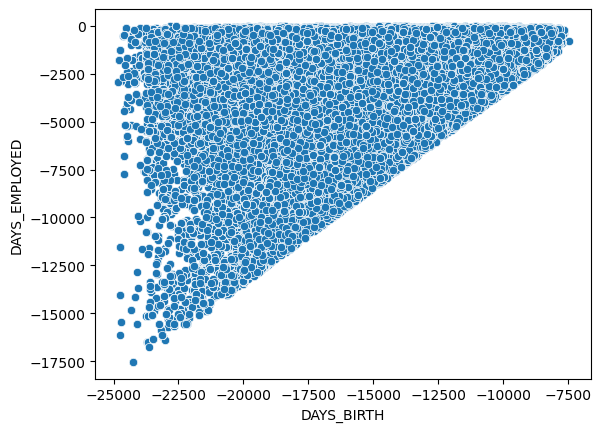

In [13]:
sns.scatterplot(data=employed, y='DAYS_EMPLOYED', x='DAYS_BIRTH')

<Axes: xlabel='DAYS_BIRTH', ylabel='DAYS_EMPLOYED'>

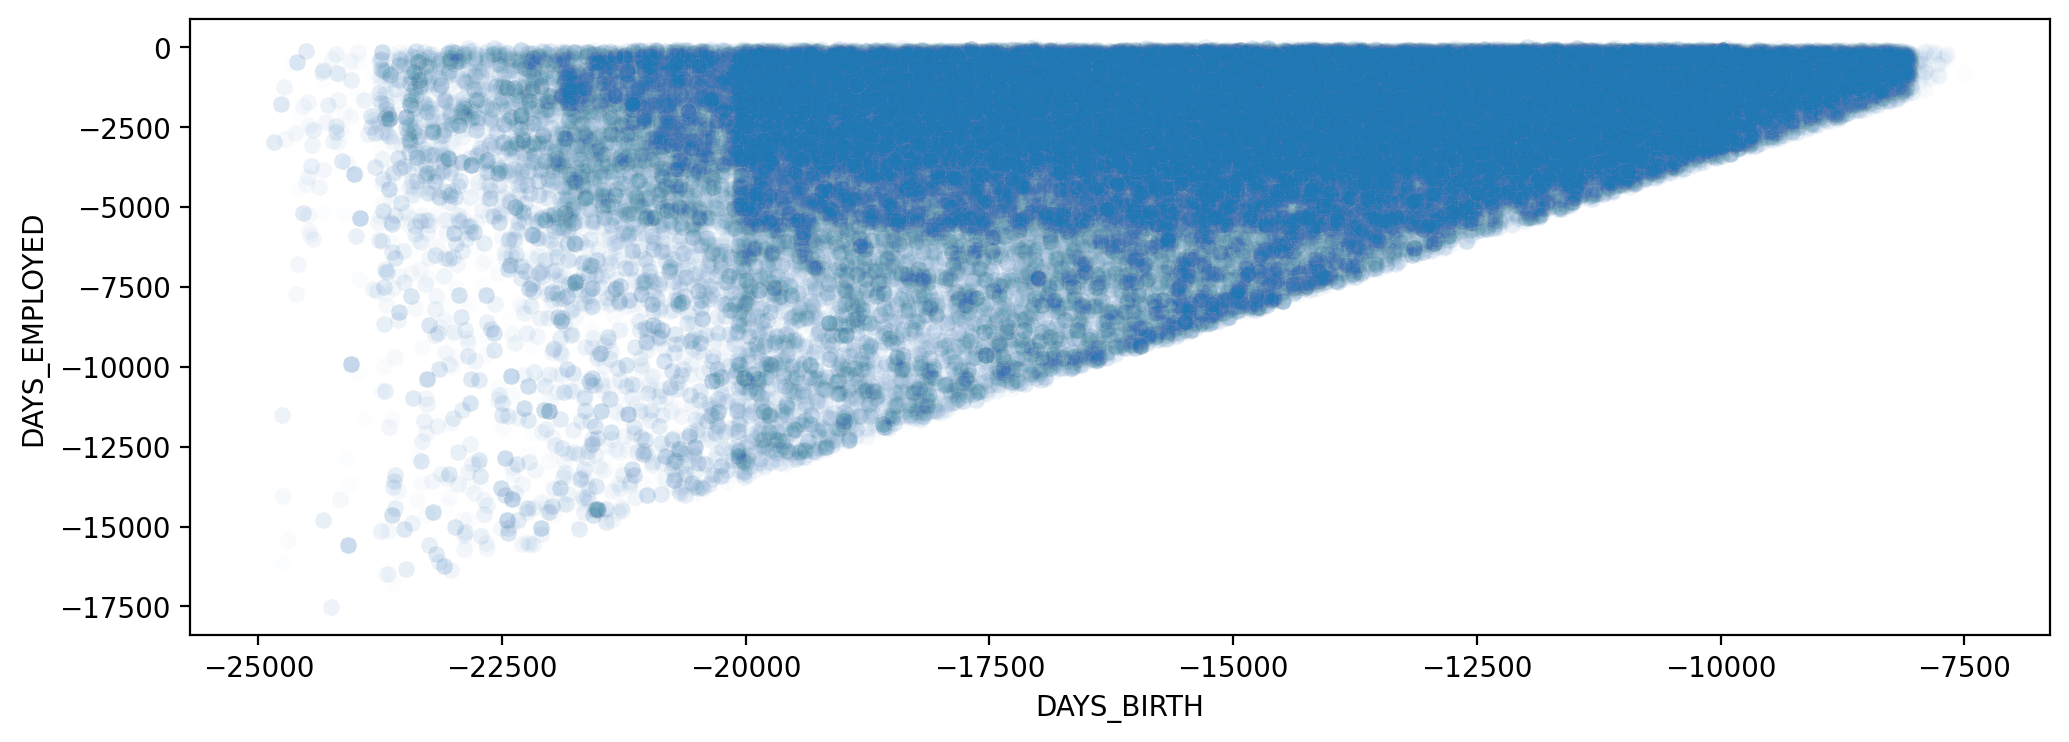

In [15]:
plt.figure(figsize=(12,4), dpi=200)
sns.scatterplot(data=employed, y='DAYS_EMPLOYED', x='DAYS_BIRTH', alpha=0.01)

<Axes: xlabel='YEARS', ylabel='Count'>

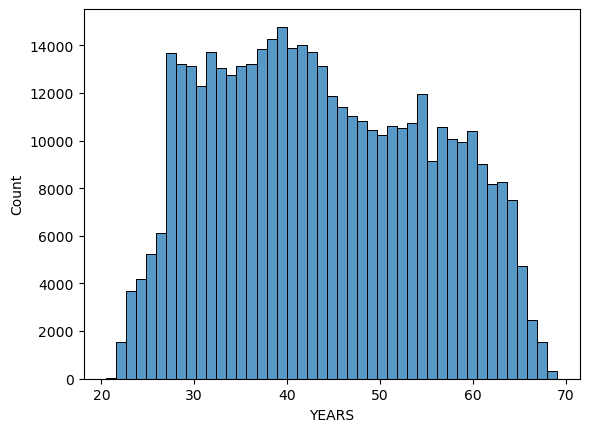

In [17]:
df['YEARS']=-1*df['DAYS_BIRTH']/365
sns.histplot(data=df, x='YEARS', bins=45)

In [20]:
int(len(df)/2)

219278

<Axes: xlabel='NAME_FAMILY_STATUS', ylabel='AMT_INCOME_TOTAL'>

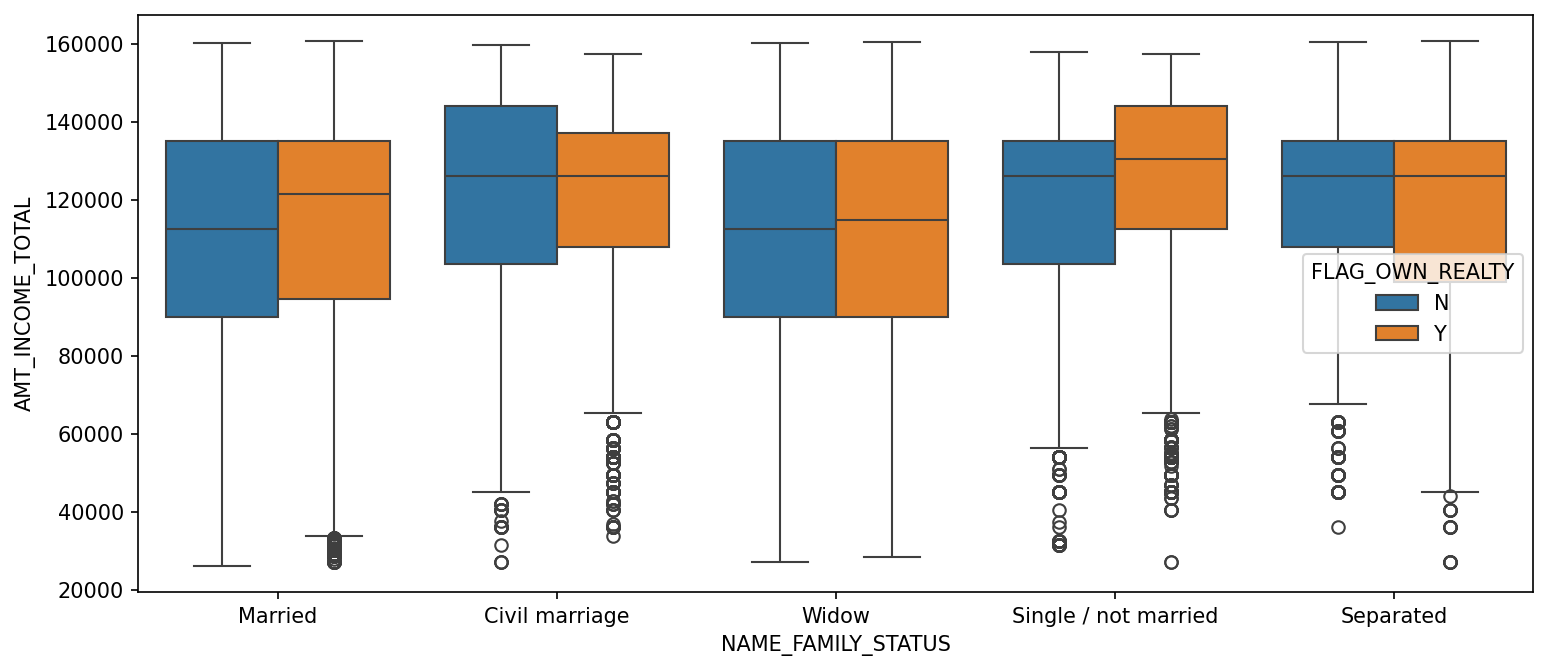

In [26]:
plt.figure(figsize = (12,5), dpi = 150)
bottom_half_income = df.nsmallest(n=219278, columns = 'AMT_INCOME_TOTAL')
sns.boxplot(data=bottom_half_income, y= 'AMT_INCOME_TOTAL', x='NAME_FAMILY_STATUS', hue= 'FLAG_OWN_REALTY')

<Axes: >

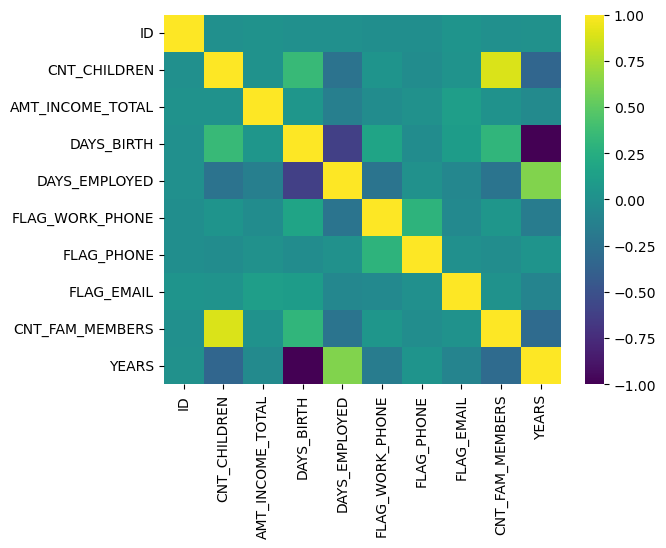

In [32]:

corr = df.drop('FLAG_MOBIL', axis=1).select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap='viridis')